# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
from cases.open_space.ngsolve_geometries import AnularDomain

R = 1.
r = 0.2


lc = 2.

mesh = AnularDomain(R=R, r=r, verbosity=0, Lc=lc, lc=lc)


In [2]:
mesh.n_triangles

106

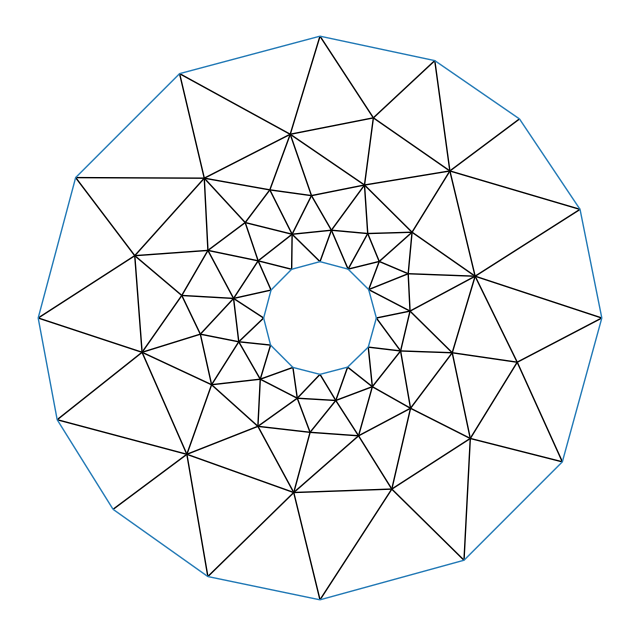

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [5]:
mesh.curve_boundaries([Boundaries.SIGMA, Boundaries.D_OMEGA], radius=[R,r])
mesh.curved_boundaries


[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

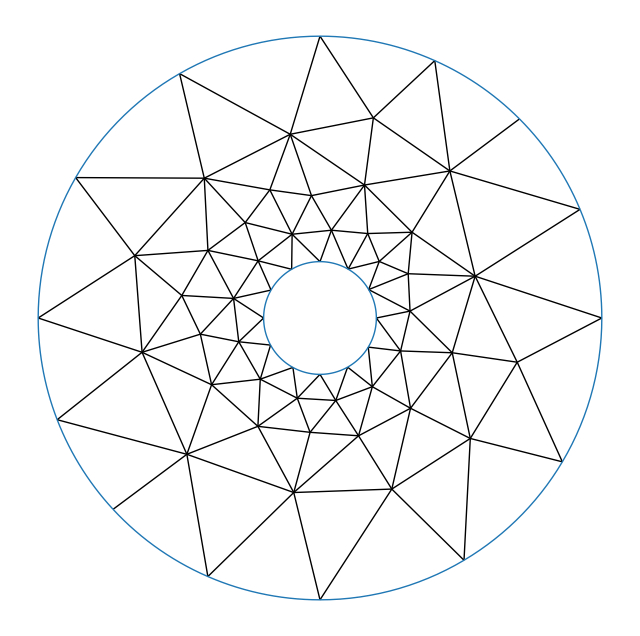

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
from trefftz.dg.exact import PlaneWave
data = PlaneWave(d=np.array([-1., 0.]), A=1.)
# boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=None), Boundaries.D_OMEGA: DirichletBC(data=data)}
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data), Boundaries.D_OMEGA: DirichletBC(data=None)}


Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [43]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5

# numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=None), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=data)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = data)})

We should also choose a local basis

In [28]:
from trefftz.dg.basis import LinearlySpacedBasis
from trefftz.dg.parameters import Elementwise

Regions = mesh.regions


refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1., Regions.OMEGA : 1.})
k = 8.0
Ntheta = 14
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [29]:
basis.N_DOF

1484

In [30]:
from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [31]:
assembler._regions_RHS_term

[<Boundaries.SIGMA: 'Sigma'>]

so we can set the problem:

In [32]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [33]:
P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 14/14 [00:00<00:00, 24.05edge/s]


region: d_Omega


Interior: 100%|██████████| 146/146 [00:00<00:00, 1173.37edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 14/14 [01:10<00:00,  5.01s/edge]


<COOrdinate sparse array of dtype 'complex128'
	with 157976 stored elements and shape (1484, 1484)>

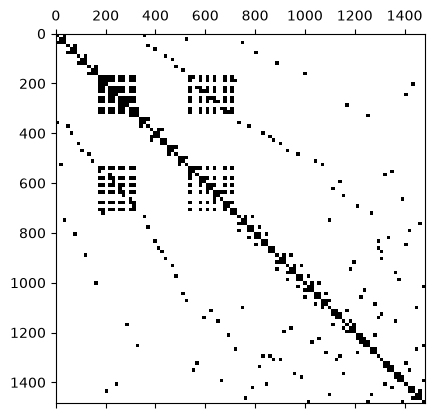

In [34]:
import matplotlib.pyplot as plt 
plt.spy(P.A.toarray())

In [35]:
P.assemble_RHS()

array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j], shape=(1484,))

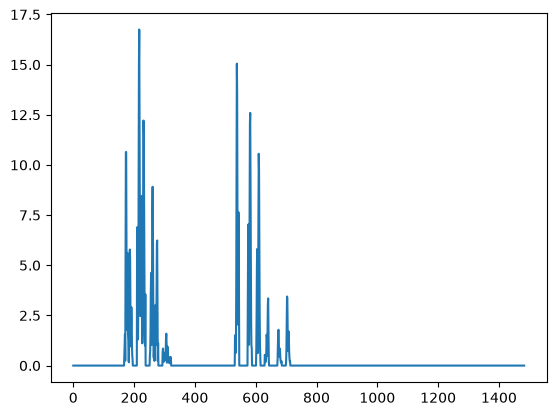

In [36]:
import numpy as np 
plt.plot(np.abs(P.b))

In [37]:
P.solve()

In [38]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 5.00656042e+03+1.03770320e+04j,  4.65326439e+03-1.12830460e+04j,
        -1.19039244e+04+5.67004366e+03j, ...,
        -1.11341508e+04+6.05454013e+03j,  1.13397256e+04-2.85606133e+03j,
        -1.06856861e+04-3.70419779e+03j],
       [ 7.23047292e+03+1.12715032e+04j,  1.96214218e+03-1.36401682e+04j,
        -8.10040286e+03+1.16939678e+04j, ...,
        -5.04308260e+03+1.20857188e+04j,  1.07542342e+04-7.32407296e+03j,
        -1.29148252e+04-2.30960404e+03j],
       [ 8.56418507e+03-5.82937274e+03j, -9.73871712e+03-3.19243915e+03j,
         5.25246144e+03+8.69775723e+03j, ...,
         9.91829243e+03+3.91302360e+03j, -7.11048864e+03-7.82195175e+03j,
        -3.78292916e+02+1.04632487e+04j],
       ...,
       [-3.44371269e+00+2.22066040e-01j,  2.16846218e-01+3.46632127e+00j,
         2.99077708e+00-1.98939962e+00j, ...,
         2.95260879e-01+3.99181692e+00j,  3.48751075e+00-1.39983485e+00j,
        -9.87443256e-01-3.39531775e+00j],
       [ 3.34454227e-01-7.01805844e+00j, -6.

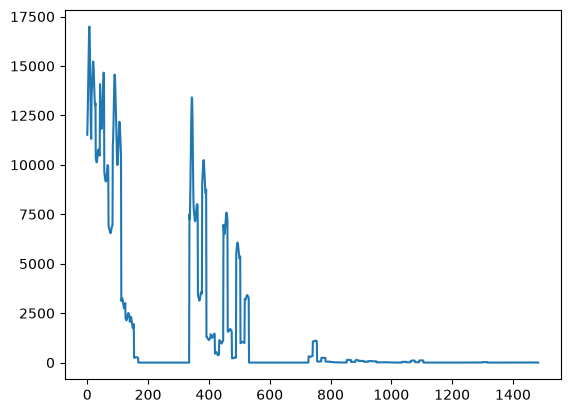

In [39]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

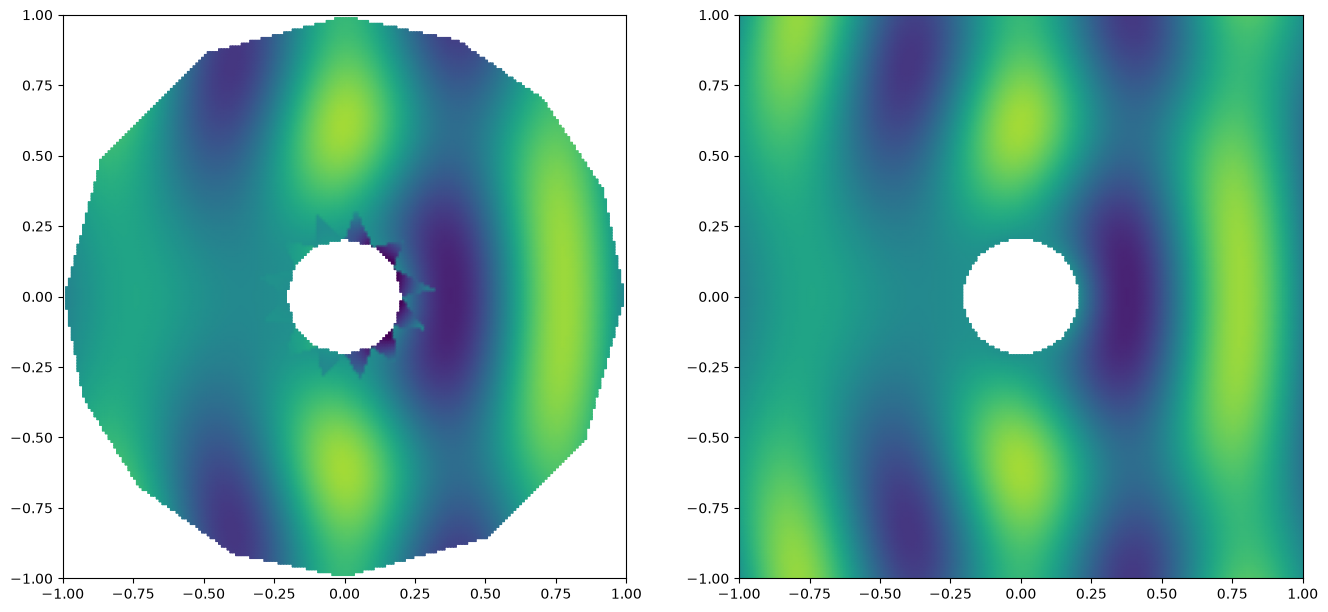

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from cases.open_space.exact import CircularDirichlet

N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = P.u_h(X, Y)
U_s = CircularDirichlet(X, Y, R=r, k=k, theta_inc=np.pi)
U_inc = np.exp(-1j*k*X)
U = U_s + U_inc
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(U.real)
vmax = np.max(U.real)


ax[0].pcolormesh(X, Y, np.real(U_h), vmin=-2, vmax=2, shading="gouraud")
ax[0].axis('square')
# ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
# ax[1].axis('square')

ax[1].pcolormesh(X, Y, np.real(U), vmin=-2, vmax=2, shading="gouraud")
ax[1].axis('square')


(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

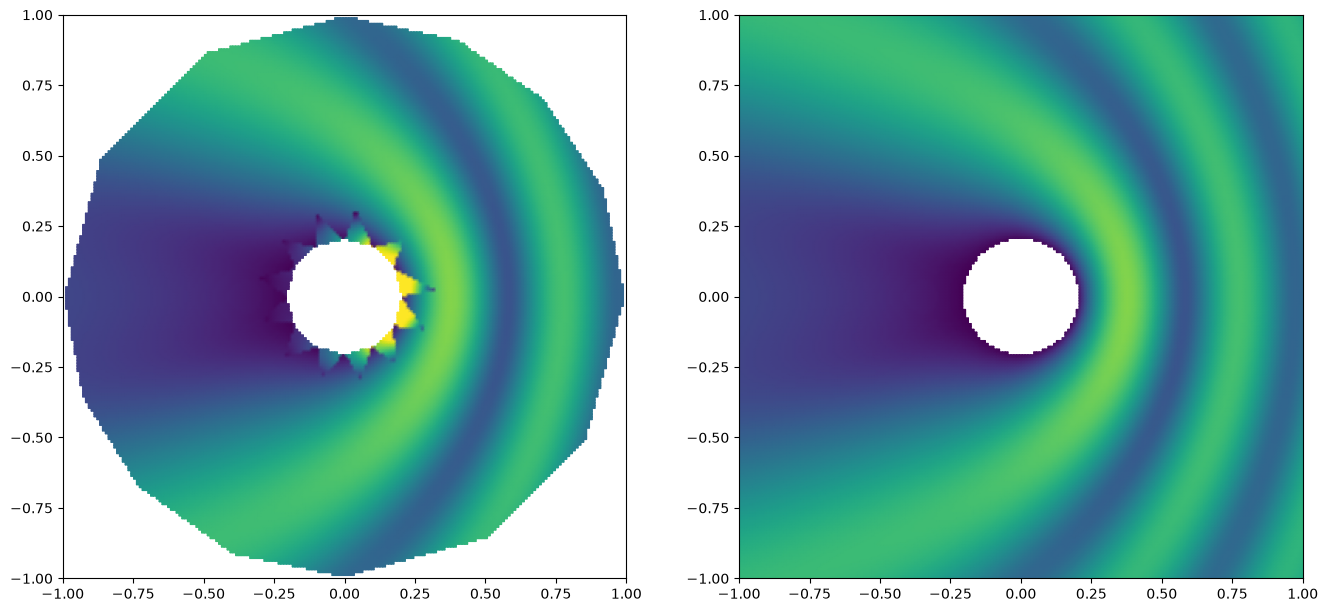

In [41]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

ax[0].pcolormesh(X, Y, np.abs(U_h), vmin=0, vmax=2, shading="gouraud")
ax[0].axis('square')

ax[1].pcolormesh(X, Y, np.abs(U), vmin=0, vmax=2, shading="gouraud")
ax[1].axis('square')


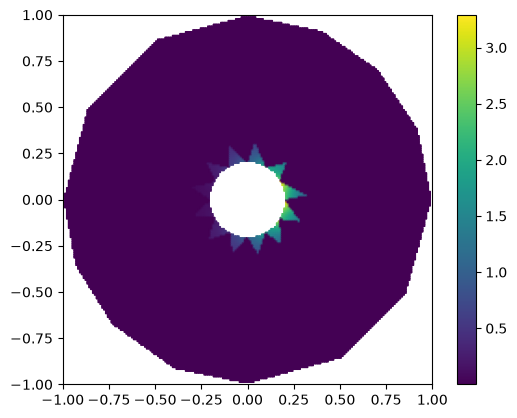

In [42]:
plt.pcolormesh(X, Y, np.abs(U - U_h), shading="gouraud")
plt.axis("square")
plt.colorbar()